In [1]:
from google.colab import files
import pandas as pd

uploaded = files.upload()
file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)


Saving final_labeled_dataset.csv to final_labeled_dataset.csv


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
import seaborn as sns

### Data Preprocessing
Hi guys so First, we check for missing values in the `headline` and `sentiment` columns and remove them. Then, we'll encode the `sentiment` labels and convert the text `headline` into numerical features using TF-IDF so that is 0 for negative 1 for neutral and 2 for positive like we did yesterday in class.

In [3]:

df.dropna(subset=['headline', 'sentiment'], inplace=True)
label_encoder = LabelEncoder()
df['sentiment_encoded'] = label_encoder.fit_transform(df['sentiment'])


print("Sentiment Label Mapping:")
for i, label in enumerate(label_encoder.classes_):
    print(f"{label}: {i}")

tfidf_vectorizer = TfidfVectorizer(max_features=5000)
X = tfidf_vectorizer.fit_transform(df['headline'])
y = df['sentiment_encoded']

Sentiment Label Mapping:
negative: 0
neutral: 1
positive: 2


### Split the data into training and testing sets

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

Training set size: 2008 samples
Testing set size: 503 samples


### Train and Tune Logistic Regression

Fitting 3 folds for each of 6 candidates, totalling 18 fits


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Best parameters for Logistic Regression: {'C': 10, 'solver': 'saga'}
Best cross-validation score for Logistic Regression: 0.7280912329235735

--- Logistic Regression Results ---
Accuracy: 0.7276341948310139
Classification Report:
               precision    recall  f1-score   support

    negative       0.73      0.85      0.79       228
     neutral       0.61      0.33      0.42        86
    positive       0.75      0.76      0.75       189

    accuracy                           0.73       503
   macro avg       0.70      0.65      0.66       503
weighted avg       0.72      0.73      0.71       503



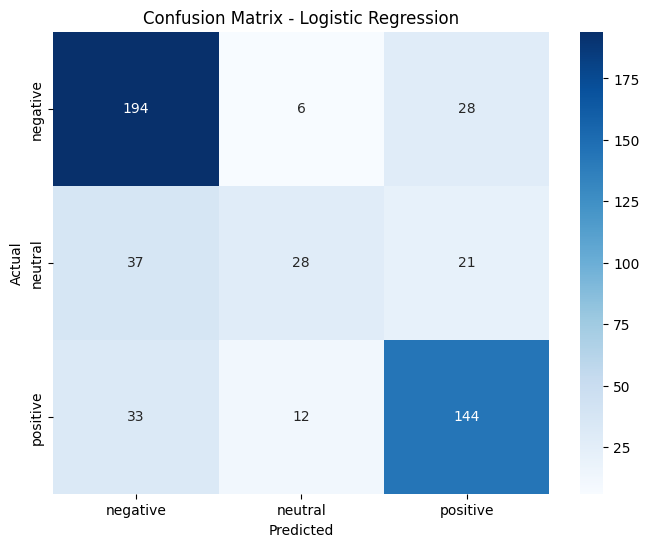

In [5]:

log_reg_params = {
    'C': [0.1, 1, 10],
    'solver': ['liblinear', 'saga']
}

log_reg_grid = GridSearchCV(LogisticRegression(max_iter=1000, multi_class='auto'), log_reg_params, cv=3, verbose=1, n_jobs=-1)
log_reg_grid.fit(X_train, y_train)

print("Best parameters for Logistic Regression:", log_reg_grid.best_params_)
print("Best cross-validation score for Logistic Regression:", log_reg_grid.best_score_)

best_log_reg = log_reg_grid.best_estimator_
y_pred_log_reg = best_log_reg.predict(X_test)

print("\n--- Logistic Regression Results ---")
print("Accuracy:", accuracy_score(y_test, y_pred_log_reg))
print("Classification Report:\n", classification_report(y_test, y_pred_log_reg, target_names=label_encoder.classes_))


cm_log_reg = confusion_matrix(y_test, y_pred_log_reg)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_log_reg, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Train and Tune Linear SVM

Fitting 3 folds for each of 3 candidates, totalling 9 fits
Best parameters for Linear SVM: {'C': 1}
Best cross-validation score for Linear SVM: 0.7236061843250118

--- Linear SVM Results ---
Accuracy: 0.7296222664015904
Classification Report:
               precision    recall  f1-score   support

    negative       0.74      0.85      0.79       228
     neutral       0.61      0.35      0.44        86
    positive       0.75      0.76      0.76       189

    accuracy                           0.73       503
   macro avg       0.70      0.65      0.66       503
weighted avg       0.72      0.73      0.72       503



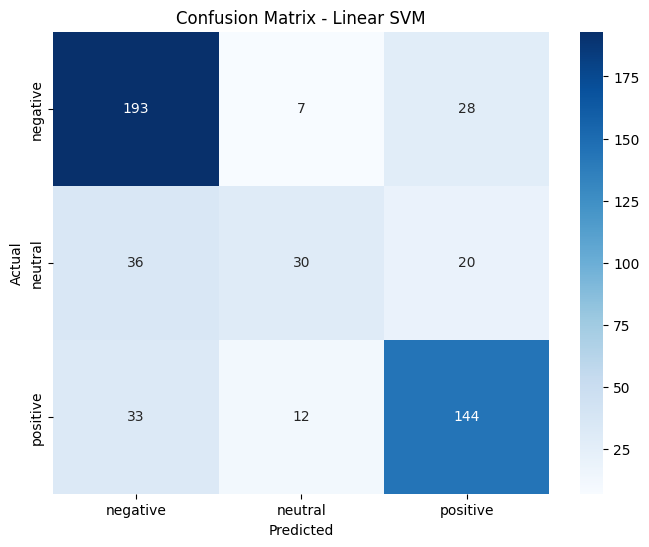

In [6]:
svm_params = {
    'C': [0.1, 1, 10]
}

svm_grid = GridSearchCV(LinearSVC(max_iter=1000), svm_params, cv=3, verbose=1, n_jobs=-1)
svm_grid.fit(X_train, y_train)

print("Best parameters for Linear SVM:", svm_grid.best_params_)
print("Best cross-validation score for Linear SVM:", svm_grid.best_score_)

best_svm = svm_grid.best_estimator_
y_pred_svm = best_svm.predict(X_test)

print("\n--- Linear SVM Results ---")
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Classification Report:\n", classification_report(y_test, y_pred_svm, target_names=label_encoder.classes_))

cm_svm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix - Linear SVM')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

###Output File with Predicted Sentiments

In [7]:

df['predicted_sentiment_log_reg'] = label_encoder.inverse_transform(best_log_reg.predict(X))

df['predicted_sentiment_svm'] = label_encoder.inverse_transform(best_svm.predict(X))

display(df[['headline', 'sentiment', 'predicted_sentiment_log_reg', 'predicted_sentiment_svm']].head())

,headline,sentiment,predicted_sentiment_log_reg,predicted_sentiment_svm
0,KBL returns to court over alleged corruption i...,negative,negative,negative
1,India's Gen Z protesters adapt to internet shu...,negative,negative,negative
2,"Who is Karim Khan, the barrister at the center...",negative,negative,negative
3,Body found dumped along Nairobi–Naivasha Highw...,negative,negative,negative
4,"Two including Italian killed, two injured in R...",negative,negative,negative


In [8]:

output_file_name = 'sentiment_predictions.csv'
df.to_csv(output_file_name, index=False)

print(f"Output file '{output_file_name}' created successfully with predicted sentiments.")

Output file 'sentiment_predictions.csv' created successfully with predicted sentiments.
